In [1]:
# 1. Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

In [2]:
import os
print(os.getcwd())

C:\Users\cxsha\PycharmProjects\Telangana_govt_ration_distribution_analysis\notebooks


In [3]:
df = pd.read_csv("C://Users//cxsha//PycharmProjects//Telangana_govt_ration_distribution_analysis//data//unified_master.csv")
df.head()

,distCode,distName_x,officeCode_x,officeName_x,shopNo,month_x,year,noOfRcs,noOfTrans,riceAfsc,...,cardPoolType,distName,officeCode,officeName,address,longitude,latitude,fpsStatus,fpsType,dateTime
0,532,Adilabad,532001,Talamadugu,1901001,10,2023,956,956,1365.0,...,NaN,Adilabad,532001,Talamadugu,DR Depo TALAMADUGU Talamadugu,78.391212,19.641643,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
1,532,Adilabad,532001,Talamadugu,1901001,10,2023,956,956,1365.0,...,NaN,Adilabad,532001,Talamadugu,DR Depo TALAMADUGU Talamadugu,78.391212,19.641643,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
2,532,Adilabad,532001,Talamadugu,1901001,10,2023,956,956,1365.0,...,NaN,Adilabad,532001,Talamadugu,DR Depo TALAMADUGU Talamadugu,78.391212,19.641643,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
3,532,Adilabad,532001,Talamadugu,1901001,10,2023,956,956,1365.0,...,NaN,Adilabad,532001,Talamadugu,DR Depo TALAMADUGU Talamadugu,78.391212,19.641643,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
4,532,Adilabad,532001,Talamadugu,1901001,10,2023,956,956,1365.0,...,NaN,Adilabad,532001,Talamadugu,DR Depo TALAMADUGU Talamadugu,78.391212,19.641643,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30


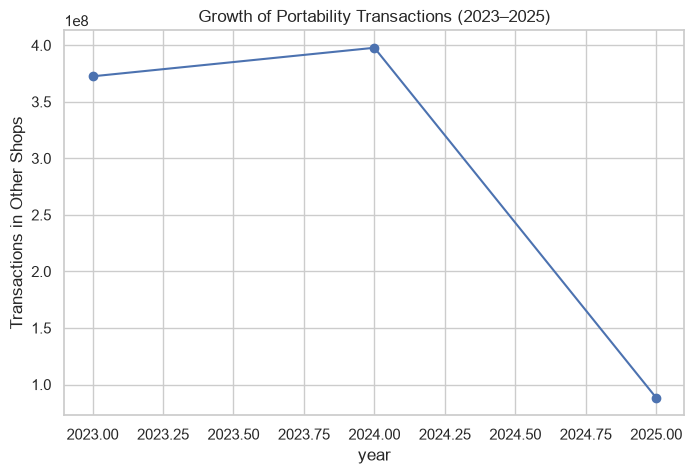

In [4]:
## 3. Portability Trend
portability_trend = df.groupby('year')['otherShopTransCnt'].sum()
plt.figure(figsize=(8,5))
portability_trend.plot(kind='line', marker='o', title="Growth of Portability Transactions (2023–2025)")
plt.ylabel("Transactions in Other Shops")
plt.show()

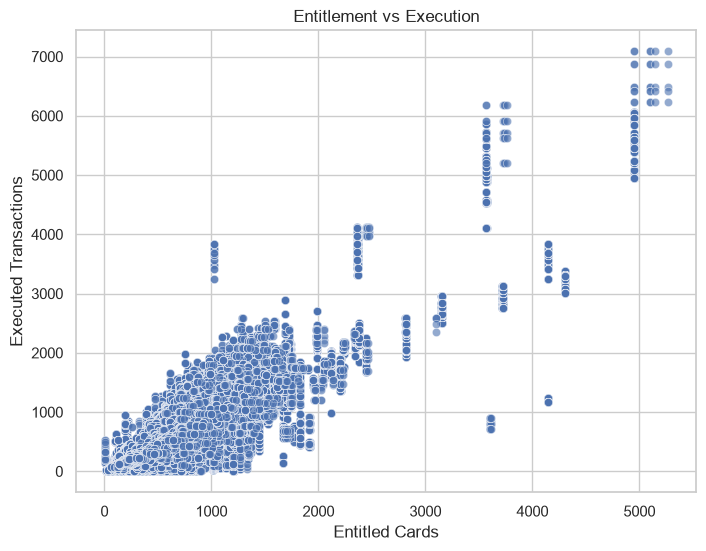

In [5]:
## 4. Entitlement vs Execution
# Scatter plot to see if shops with more entitled ration cards also execute more transactions.
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='totalRcs', y='noOfTrans', alpha=0.6)
plt.title("Entitlement vs Execution")
plt.xlabel("Entitled Cards")
plt.ylabel("Executed Transactions")
plt.show()

In [6]:
correlation = df['totalRcs'].corr(df['noOfTrans'])
print("Correlation between totalRcs and noOfTrans:", correlation)

Correlation between totalRcs and noOfTrans: 0.8789798810854383


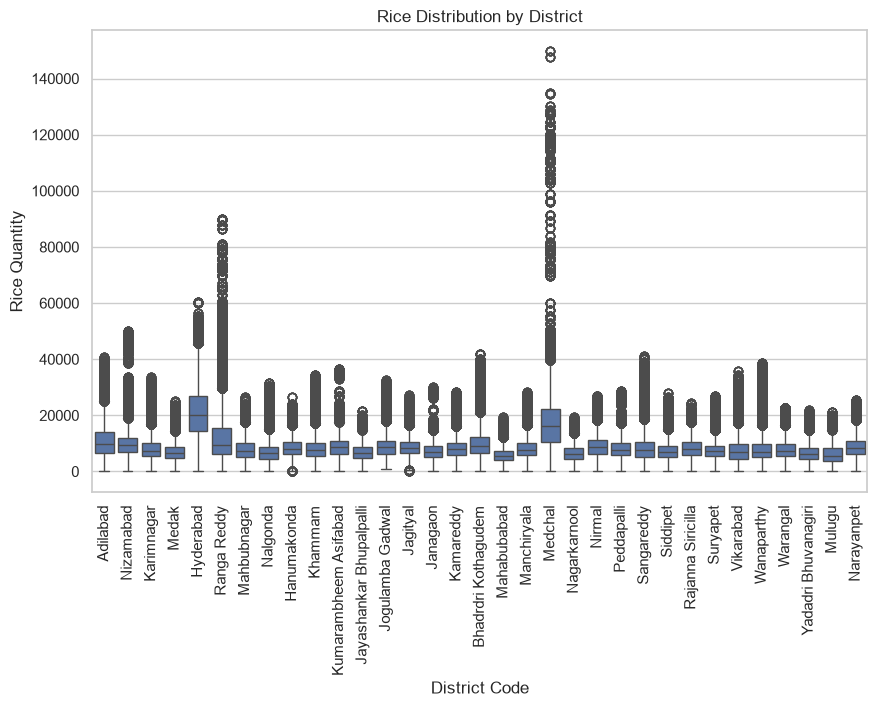

In [10]:
## 5. Commodity Distribution - Rice & Wheat

commodities = ['riceAfsc','riceFsc','riceAap','wheat']

df['rice_total'] = df['riceAfsc'] + df['riceFsc'] + df['riceAap']
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='distName_y', y='rice_total')
plt.title("Rice Distribution by District")
plt.xlabel("District Code")
plt.ylabel("Rice Quantity")
plt.xticks(rotation=90)
plt.show()


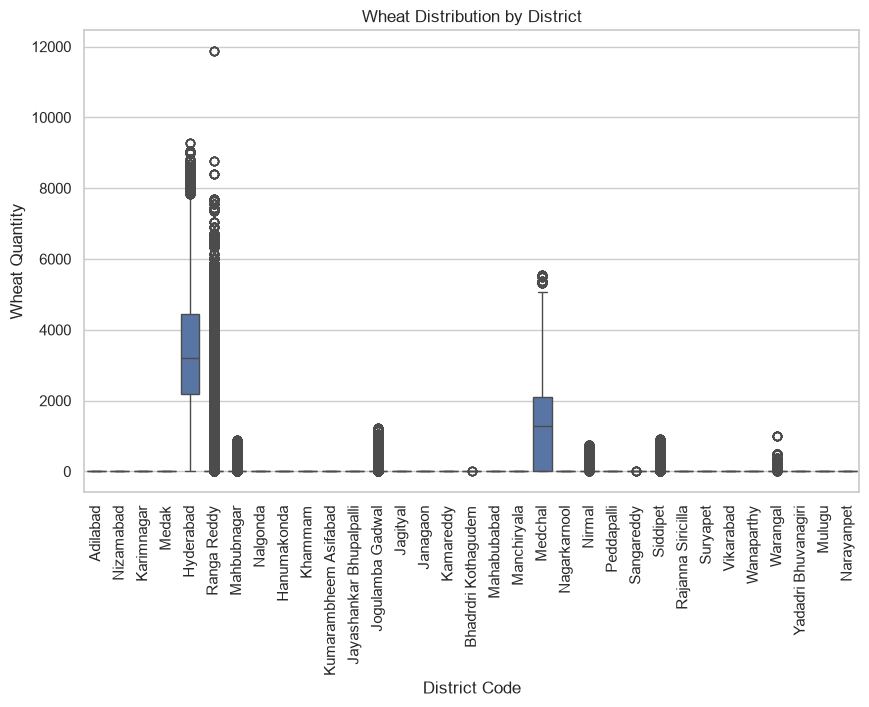

In [8]:
# Wheat Distribution
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='distName_y', y='wheat')
plt.title("Wheat Distribution by District")
plt.xlabel("District Code")
plt.ylabel("Wheat Quantity")
plt.xticks(rotation=90)
plt.show()

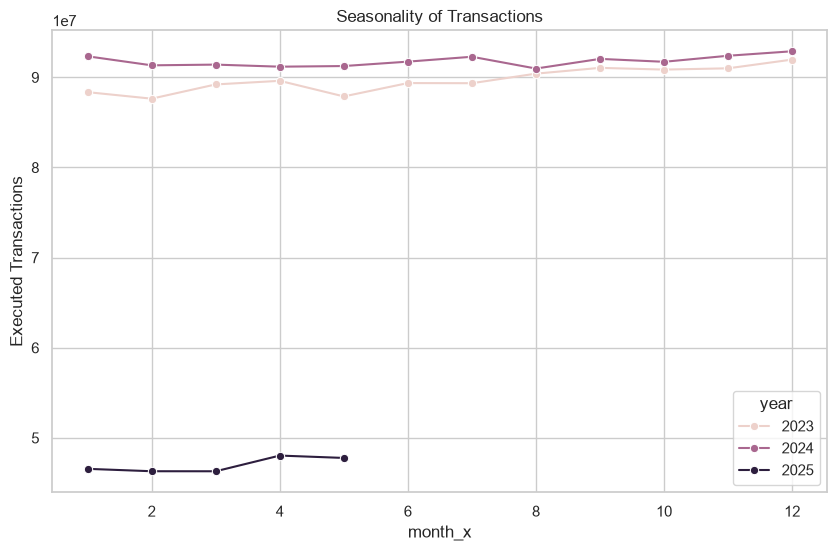

In [18]:
# If month column exists
if 'month_x' in df.columns:
    monthly_trend = df.groupby(['year','month_x'])['noOfTrans'].sum().reset_index()
    plt.figure(figsize=(10,6))
    sns.lineplot(data=monthly_trend, x='month_x', y='noOfTrans', hue='year', marker='o')
    plt.title("Seasonality of Transactions")
    plt.xlabel("month_x")
    plt.ylabel("Executed Transactions")
    plt.show()
else:
    print("No month column available in dataset.")